# 1. Import Libraries

In [1]:
# =====================================================
# 1. Import Libraries
# =====================================================

import warnings
warnings.filterwarnings("ignore")

import timeit
import joblib

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    OneHotEncoder,
    LabelEncoder,
    PolynomialFeatures
)
from category_encoders import BinaryEncoder

# Feature Selection
from sklearn.feature_selection import SequentialFeatureSelector

# Train-Test Split & Validation
from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    GridSearchCV
)

# Pipelines
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline

# Handling Imbalanced Data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Sampling Objects
over = SMOTE(random_state=27)
under = RandomUnderSampler(random_state=27)

# 2. Load Clean Dataset

In [2]:
# =====================================================
# 2. Load Clean Dataset
# =====================================================

df = pd.read_csv("hotel_bookings_cleaned.csv")

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,No Deposit,0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,No Deposit,304,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
# Dataset Shape

print("Dataset Shape:", df.shape)

Dataset Shape: (87203, 31)


In [4]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87203 entries, 0 to 87202
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87203 non-null  object 
 1   is_canceled                     87203 non-null  int64  
 2   lead_time                       87203 non-null  int64  
 3   arrival_date_year               87203 non-null  int64  
 4   arrival_date_month              87203 non-null  object 
 5   arrival_date_week_number        87203 non-null  int64  
 6   arrival_date_day_of_month       87203 non-null  int64  
 7   stays_in_weekend_nights         87203 non-null  int64  
 8   stays_in_week_nights            87203 non-null  int64  
 9   adults                          87203 non-null  int64  
 10  children                        87203 non-null  int64  
 11  babies                          87203 non-null  int64  
 12  meal                            

In [5]:
# Check Missing Values

df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

In [6]:
df.duplicated().sum()

0

# 3. Feature Engineering

## 3.1 Total Nights

In [7]:
# =====================================================
# Create Total Nights Feature
# =====================================================

df["total_nights"] = (
    df["stays_in_weekend_nights"] +
    df["stays_in_week_nights"]
)

df["total_nights"].head()

0    0
1    0
2    1
3    1
4    2
Name: total_nights, dtype: int64

## 3.2 Total Guests

In [8]:
# =====================================================
# Create Total Guests Feature
# =====================================================

df["total_guests"] = (
    df["adults"] +
    df["children"] +
    df["babies"]
)

df["total_guests"].head()

0    2
1    2
2    1
3    1
4    2
Name: total_guests, dtype: int64

## 3.3 Is Family

In [9]:
# =====================================================
# Create Family Indicator
# =====================================================
# If the booking includes children or babies,
# it is considered a family booking.

df["is_family"] = (
    (df["children"] + df["babies"]) > 0
).astype(int)

df["is_family"].value_counts()

is_family
0    78100
1     9103
Name: count, dtype: int64

## 3.4 ADR per Guest

In [10]:
# =====================================================
# Create ADR per Guest
# =====================================================
# Calculate the Average Daily Rate (ADR) per guest.
# Replace infinite and missing values resulting from division by zero.

df["adr_per_guest"] = df["adr"] / df["total_guests"]

df["adr_per_guest"] = df["adr_per_guest"].replace(
    [np.inf, -np.inf],
    0
)

df["adr_per_guest"] = df["adr_per_guest"].fillna(0)

df["adr_per_guest"].head()

0     0.0
1     0.0
2    75.0
3    75.0
4    49.0
Name: adr_per_guest, dtype: float64

## 3.5 Verify Engineered Features

In [11]:
# =====================================================
# Verify Engineered Features
# =====================================================

# Preview the engineered features
# to ensure they were created successfully.

df[[
    "total_nights",
    "total_guests",
    "is_family",
    "adr_per_guest"
]].head()

,total_nights,total_guests,is_family,adr_per_guest
0,0,2,0,0.0
1,0,2,0,0.0
2,1,1,0,75.0
3,1,1,0,75.0
4,2,2,0,49.0


# 4. Feature Selection

In [12]:
# Remove features that cause data leakage.

df = df.drop(
    columns=[
        "reservation_status",
        "reservation_status_date"
    ]
)

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_nights,total_guests,is_family,adr_per_guest
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,0,Transient,0.0,0,0,0,2,0,0.0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,0,Transient,0.0,0,0,0,2,0,0.0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,0,Transient,75.0,0,0,1,1,0,75.0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,304,0,Transient,75.0,0,0,1,1,0,75.0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,240,0,Transient,98.0,0,1,2,2,0,49.0


Observation

'reservation_status' was removed because it directly
reveals whether the booking was canceled or not.

'reservation_status_date' was removed because it is
generated after the booking outcome, making it unavailable
at the time of prediction.

In [13]:
# =====================================================
# Check Remaining Features
# =====================================================

print(f"Number of Features: {df.shape[1]}")

df.columns

Number of Features: 33


Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'total_nights', 'total_guests', 'is_family', 'adr_per_guest'],
      dtype='object')

# 5. Separate Features and Target

In [14]:
# Separate the features (X) and the target variable (y)

X = df.drop("is_canceled", axis=1)
y = df["is_canceled"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (87203, 32)
Target Shape: (87203,)


# 6. Split the Dataset

In [15]:
# Split the dataset into training and testing sets.

# The dataset was split into 80% training data and
# 20% testing data while preserving the class
# distribution using stratification.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape :", X_test.shape)

Training Set Shape: (69762, 32)
Testing Set Shape : (17441, 32)


# 7. Data Preprocessing 

## 7.1 Define Categorical and Numerical Features

In [16]:
# =====================================================
#  Define Categorical and Numerical Features
# =====================================================

# Categorical and numerical features were identified
# automatically based on their data types. This approach
# makes the preprocessing pipeline more flexible and
# easier to maintain.

categorical_features = X_train.select_dtypes(include="object").columns.tolist()

numerical_features = X_train.select_dtypes(exclude="object").columns.tolist()

print("Categorical Features:", len(categorical_features))
print(categorical_features)

print("\nNumerical Features:", len(numerical_features))
print(numerical_features)

Categorical Features: 10
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

Numerical Features: 22
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_nights', 'total_guests', 'is_family', 'adr_per_guest']


## 7.2 Create Preprocessing Pipeline

In [17]:
# =====================================================
#  Create Preprocessing Pipeline
# =====================================================

# One-Hot Encoding was applied to categorical
# variables, while Standard Scaling was applied
# to numerical variables.

Encoder = ColumnTransformer(

    transformers=[

        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),

        (
            "numerical",
            StandardScaler(),
            numerical_features
        )

    ]
)

# 8. Define Machine Learning Models

In [18]:
# Define the machine learning models to be evaluated.

# Multiple machine learning algorithms were selected
# to compare their performance and identify the most
# suitable model for predicting hotel booking cancellations.

models = []

models.append(("Logistic Regression", LogisticRegression(max_iter=1000)))
models.append(("KNN", KNeighborsClassifier()))
models.append(("Decision Tree", DecisionTreeClassifier(random_state=42)))
models.append(("Random Forest", RandomForestClassifier(random_state=42)))
models.append(("XGBoost", XGBClassifier(random_state=42)))

# 9. Model Evaluation using Cross Validation

## 9.1 Define Cross Validation Strategy

In [19]:
# =====================================================
#  Define Cross Validation Strategy
# =====================================================

# Stratified K-Fold preserves the class distribution
# across all folds, resulting in a fair model
# evaluation.

from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## 9.2 Evaluate Machine Learning Models

In [20]:
# =====================================================
#  Evaluate Machine Learning Models
# =====================================================

# Five-fold Stratified Cross Validation was used to
# compare all machine learning models using Accuracy,
# Precision, Recall, F1-Score, and execution time.

results = []

for name, model in models:

    start = timeit.default_timer()

    pipeline = Pipeline([

        ("Encoder", Encoder),
        ("SMOTE", over),
        ("Model", model)

    ])

    scores = cross_validate(

        estimator=pipeline,

        X=X_train,
        y=y_train,

        cv=cv,

        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1"
        ],

        return_train_score=True,

        n_jobs=1

    )

    stop = timeit.default_timer()

    print(f"\n{name}")
    print("="*60)

    print("Train Accuracy :", round(scores["train_accuracy"].mean(),4))
    print("Test Accuracy  :", round(scores["test_accuracy"].mean(),4))

    print("-"*40)

    print("Train Precision :", round(scores["train_precision"].mean(),4))
    print("Test Precision  :", round(scores["test_precision"].mean(),4))

    print("-"*40)

    print("Train Recall :", round(scores["train_recall"].mean(),4))
    print("Test Recall  :", round(scores["test_recall"].mean(),4))

    print("-"*40)

    print("Train F1 Score :", round(scores["train_f1"].mean(),4))
    print("Test F1 Score  :", round(scores["test_f1"].mean(),4))

    print("-"*40)

    print("Run Time :", round(stop-start,2),"Seconds")

    print("="*60)

    results.append({

        "Model":name,
        "Accuracy":round(scores["test_accuracy"].mean(),4),
        "Precision":round(scores["test_precision"].mean(),4),
        "Recall":round(scores["test_recall"].mean(),4),
        "F1 Score":round(scores["test_f1"].mean(),4),
        "Run Time (sec)":round(stop-start,2)

    })


Logistic Regression
Train Accuracy : 0.7579
Test Accuracy  : 0.7564
----------------------------------------
Train Precision : 0.5417
Test Precision  : 0.5398
----------------------------------------
Train Recall : 0.7838
Test Recall  : 0.7809
----------------------------------------
Train F1 Score : 0.6407
Test F1 Score  : 0.6383
----------------------------------------
Run Time : 131.67 Seconds

KNN
Train Accuracy : 0.8062
Test Accuracy  : 0.6987
----------------------------------------
Train Precision : 0.5922
Test Precision  : 0.4722
----------------------------------------
Train Recall : 0.9511
Test Recall  : 0.8018
----------------------------------------
Train F1 Score : 0.7299
Test F1 Score  : 0.5944
----------------------------------------
Run Time : 2119.55 Seconds

Decision Tree
Train Accuracy : 0.9979
Test Accuracy  : 0.7927
----------------------------------------
Train Precision : 0.9994
Test Precision  : 0.618
----------------------------------------
Train Recall : 0.99

# 10. Model Comparison

In [21]:
# =====================================================
#  Model Comparison
# =====================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,Run Time (sec)
0,XGBoost,0.8445,0.7275,0.6957,0.7112,73.74
1,Random Forest,0.8458,0.7472,0.6651,0.7037,1014.06
2,Logistic Regression,0.7564,0.5398,0.7809,0.6383,131.67
3,Decision Tree,0.7927,0.6180,0.6466,0.6319,131.95
4,KNN,0.6987,0.4722,0.8018,0.5944,2119.55


Observation

 XGBoost achieved the highest F1 Score (0.7112)
 while requiring the shortest execution time among
 the top-performing models. Therefore, XGBoost was
 selected as the best candidate for hyperparameter
 tuning.

# 11. Hyperparameter Tuning

## 11.1 Define Parameter Grid

In [22]:
# =====================================================
#  Define Parameter Grid
# =====================================================
# Hyperparameter tuning was performed to improve the
# performance of the XGBoost model. Instead of using
# the default parameters, multiple combinations of
# important parameters were tested to find the best
# configuration that maximizes the F1 Score.

param_grid = {

    "Model__n_estimators": [100, 200],

    "Model__max_depth": [3, 5, 7],

    "Model__learning_rate": [0.01, 0.1],

    "Model__subsample": [0.8, 1.0]

}

## 11.2 Create Pipeline

In [23]:
# =====================================================
#  Create Pipeline
# =====================================================
# A machine learning pipeline was created to combine
# preprocessing, data balancing using SMOTE, and the
# XGBoost model into one workflow. This ensures that
# every fold during cross-validation applies the same
# preprocessing steps without data leakage.

xgb_pipeline = Pipeline([

    ("Encoder", Encoder),

    ("SMOTE", over),

    ("Model", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))

])

## 11.3 Grid Search

In [26]:
# =====================================================
#  Hyperparameter Tuning
# =====================================================
# GridSearchCV evaluated different combinations of
# XGBoost hyperparameters using Stratified 5-Fold
# Cross Validation. The model with the highest average
# F1 Score was automatically selected as the best model.

start = timeit.default_timer()

grid_search = GridSearchCV(

    estimator=xgb_pipeline,

    param_grid=param_grid,

    cv=cv,

    scoring="f1",

    n_jobs=1,

    verbose=1,

    error_score="raise"

)

grid_search.fit(X_train, y_train)

stop = timeit.default_timer()

Fitting 5 folds for each of 24 candidates, totalling 120 fits


## 11.4 Best Parameters

In [27]:
grid_search.cv_results_["mean_test_score"]

array([0.61178882, 0.61215365, 0.6304614 , 0.62587973, 0.65168497,
       0.65126039, 0.6326858 , 0.63513072, 0.66398834, 0.66317395,
       0.67107767, 0.6684283 , 0.6445849 , 0.64231157, 0.67328822,
       0.66717937, 0.67513916, 0.67032452, 0.70042438, 0.69522124,
       0.69711957, 0.69322501, 0.71430775, 0.7099675 ])

In [28]:
# =====================================================
#  Best Parameters
# =====================================================

print("Best Parameters:")

print(grid_search.best_params_)

print("\nBest F1 Score:")

print(round(grid_search.best_score_,4))

print("\nRun Time:")

print(round(stop-start,2),"Seconds")

Best Parameters:
{'Model__learning_rate': 0.1, 'Model__max_depth': 7, 'Model__n_estimators': 200, 'Model__subsample': 0.8}

Best F1 Score:
0.7143

Run Time:
2094.72 Seconds



 Observation


 Hyperparameter tuning slightly improved the model
 performance. The optimized XGBoost model achieved
 the highest cross-validation F1 Score (0.7143), making it the final model selected for evaluation
 on the unseen test dataset.

# 12. Final Model Evaluation

## 12.1 Train Best Model

In [29]:
# =====================================================
# Train Best Model
# =====================================================
# The optimized XGBoost model was retrained using
# the entire training dataset before evaluating
# its performance on the unseen test set.
best_model = grid_search.best_estimator_

best_model.fit(X_train, y_train)

,steps,"[('Encoder', ...), ('SMOTE', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 12.2 Predict Test Data

In [30]:
# =====================================================
# Predict Test Data
# =====================================================
# Predictions were generated for the unseen test
# dataset to evaluate the model's generalization
# performance.
y_pred = best_model.predict(X_test)

## 12.3 Evaluation Metrics

In [31]:
# =====================================================
#  Model Evaluation
# =====================================================
# The optimized XGBoost model was evaluated using
# four classification metrics. The F1 Score is
# considered the primary metric because it balances
# precision and recall.

print("Accuracy :", round(accuracy_score(y_test, y_pred),4))
print("Precision:", round(precision_score(y_test, y_pred),4))
print("Recall   :", round(recall_score(y_test, y_pred),4))
print("F1 Score :", round(f1_score(y_test, y_pred),4))

Accuracy : 0.856
Precision: 0.7482
Recall   : 0.7191
F1 Score : 0.7334


 Observation

The optimized XGBoost model achieved an accuracy of
 85.60% and an F1 Score of 73.34% on the unseen test
 dataset.
 
  These results indicate that the model
 generalizes well and provides a good balance between
 precision and recall for predicting booking
 cancellations.

## 12.4 Confusion Matrix

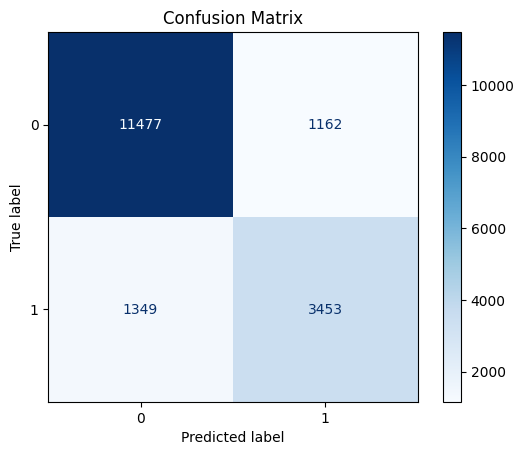

In [32]:
# =====================================================
#  Confusion Matrix
# =====================================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

|              |    Predicted 0 |   Predicted 1 |
| ------------ | -------------: | ------------: |
| **Actual 0** | **11477 (TN)** | **1162 (FP)** |
| **Actual 1** |  **1349 (FN)** | **3453 (TP)** |



Observation

 The confusion matrix shows that the XGBoost model
 correctly classified most booking cancellations and
 non-cancellations.
 
  Although some false positives and
 false negatives remain, the overall prediction
 performance is balanced and consistent with the
 achieved F1 Score.

## 12.5 Classification Report

In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90     12639
           1       0.75      0.72      0.73      4802

    accuracy                           0.86     17441
   macro avg       0.82      0.81      0.82     17441
weighted avg       0.85      0.86      0.86     17441



 Observation

 The classification report confirms that the
 optimized XGBoost model achieved balanced
 performance on both classes.
 
 It obtained an overall accuracy of 85.6% and an F1 Score of
 73% for predicting booking cancellations,
 indicating good generalization on unseen data.

# 13. Save Final Model

In [34]:
# =====================================================
#  Save Final Model
# =====================================================

import joblib

joblib.dump(best_model, "best_xgboost_model.pkl")

print("Model saved successfully.")

Model saved successfully.
